In [7]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [8]:
!kaggle datasets download -d kritikseth/fruit-and-vegetable-image-recognition

Dataset URL: https://www.kaggle.com/datasets/kritikseth/fruit-and-vegetable-image-recognition
License(s): CC0-1.0
fruit-and-vegetable-image-recognition.zip: Skipping, found more recently modified local copy (use --force to force download)


In [9]:
import zipfile

zip_path = "fruit-and-vegetable-image-recognition.zip"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    file_list = zip_ref.namelist()

for file in file_list[:30]:
    print(file)

test/apple/Image_1.jpg
test/apple/Image_10.jpg
test/apple/Image_2.jpg
test/apple/Image_3.jpg
test/apple/Image_4.jpg
test/apple/Image_5.jpg
test/apple/Image_6.JPG
test/apple/Image_7.jpg
test/apple/Image_8.jpg
test/apple/Image_9.jpg
test/banana/Image_1.jpg
test/banana/Image_10.jpg
test/banana/Image_2.jpg
test/banana/Image_3.jpg
test/banana/Image_4.jpg
test/banana/Image_5.jpg
test/banana/Image_6.jpg
test/banana/Image_8.jpg
test/banana/Image_9.jpg
test/beetroot/Image_1.jpg
test/beetroot/Image_10.jpg
test/beetroot/Image_2.jpg
test/beetroot/Image_3.jpg
test/beetroot/Image_4.jpg
test/beetroot/Image_5.jpg
test/beetroot/Image_6.jpg
test/beetroot/Image_7.jpg
test/beetroot/Image_8.jpg
test/beetroot/Image_9.jpg
test/bell pepper/Image_1.jpg


In [10]:
import os
import zipfile

zip_path = "fruit-and-vegetable-image-recognition.zip"
output_dir = "dataset"

selected_classes = [
    "apple",
    "banana",
    "bell pepper",
    "carrot",
    "grapes",
    "kiwi",
    "lemon",
    "orange",
    "pear",
    "tomato"
]

selected_splits = ["train", "validation", "test"]

os.makedirs(output_dir, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    all_files = zip_ref.namelist()

    selected_files = []

    for file in all_files:
        file_lower = file.lower()

        for split in selected_splits:
            for class_name in selected_classes:
                target_path = f"{split}/{class_name}/"

                if file_lower.startswith(target_path):
                    selected_files.append(file)
                    break

    print("Number of selected files:", len(selected_files))

    for file in selected_files:
        zip_ref.extract(file, output_dir)

print("Selected 10 classes extracted successfully.")

Number of selected files: 1029
Selected 10 classes extracted successfully.


In [11]:
import os

DATASET_DIR = "dataset"

print(os.listdir(DATASET_DIR))
print(os.listdir(os.path.join(DATASET_DIR, "train")))
print(os.listdir(os.path.join(DATASET_DIR, "validation")))
print(os.listdir(os.path.join(DATASET_DIR, "test")))

['train', 'validation', 'test']
['apple', 'tomato', 'pear', 'bell pepper', 'carrot', 'lemon', 'kiwi', 'grapes', 'banana', 'orange']
['apple', 'tomato', 'pear', 'bell pepper', 'carrot', 'lemon', 'kiwi', 'grapes', 'banana', 'orange']
['apple', 'tomato', 'pear', 'bell pepper', 'carrot', 'lemon', 'kiwi', 'grapes', 'banana', 'orange']


In [12]:
TRAIN_DIR = os.path.join(DATASET_DIR, "train")
VAL_DIR = os.path.join(DATASET_DIR, "validation")
TEST_DIR = os.path.join(DATASET_DIR, "test")

print("Train path:", TRAIN_DIR)
print("Validation path:", VAL_DIR)
print("Test path:", TEST_DIR)

Train path: dataset/train
Validation path: dataset/validation
Test path: dataset/test


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Dataset Description & Configuration

## Count Images per Class in Train / Validation / Test


In [14]:
import os
import pandas as pd

DATASET_DIR = "dataset"

TRAIN_DIR = os.path.join(DATASET_DIR, "train")
VAL_DIR = os.path.join(DATASET_DIR, "validation")
TEST_DIR = os.path.join(DATASET_DIR, "test")

selected_classes = [
    "apple",
    "banana",
    "bell pepper",
    "carrot",
    "grapes",
    "kiwi",
    "lemon",
    "orange",
    "pear",
    "tomato"
]

valid_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

def count_images_in_class(folder_path, class_name):
    class_path = os.path.join(folder_path, class_name)

    if not os.path.exists(class_path):
        print(f"Warning: Folder not found -> {class_path}")
        return 0

    image_count = len([
        file for file in os.listdir(class_path)
        if file.lower().endswith(valid_extensions)
    ])

    return image_count

data = []

for class_name in selected_classes:
    train_count = count_images_in_class(TRAIN_DIR, class_name)
    val_count = count_images_in_class(VAL_DIR, class_name)
    test_count = count_images_in_class(TEST_DIR, class_name)

    data.append({
        "Class": class_name,
        "Train": train_count,
        "Validation": val_count,
        "Test": test_count,
        "Total": train_count + val_count + test_count
    })

df_counts = pd.DataFrame(data)
df_counts

,Class,Train,Validation,Test,Total
0,apple,68,10,10,88
1,banana,75,9,9,93
2,bell pepper,90,9,10,109
3,carrot,82,9,10,101
4,grapes,100,9,10,119
5,kiwi,88,10,10,108
6,lemon,82,10,10,102
7,orange,69,9,10,88
8,pear,89,10,10,109
9,tomato,92,10,10,112


## Plot class distribution

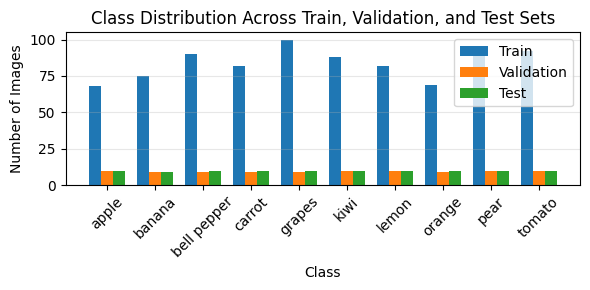

In [15]:
plt.figure(figsize=(6,3))

x = range(len(df_counts["Class"]))

plt.bar([i - 0.25 for i in x], df_counts["Train"], width=0.25, label="Train")
plt.bar(x, df_counts["Validation"], width=0.25, label="Validation")
plt.bar([i + 0.25 for i in x], df_counts["Test"], width=0.25, label="Test")

plt.title("Class Distribution Across Train, Validation, and Test Sets")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(x, df_counts["Class"], rotation=45)
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

A grouped bar chart was created to compare the class distribution across the three splits. This helps identify whether the dataset is balanced or imbalanced.

If the number of samples is similar across classes, accuracy can be a reasonable evaluation metric. However, if some classes have many more images than others, accuracy may become misleading.

## Resize Images to 128×128 and Standardize to RGB 🖼️

In [16]:
import os
from PIL import Image

IMAGE_SIZE = (128, 128)
valid_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

selected_classes = [
    "apple",
    "banana",
    "bell pepper",
    "carrot",
    "grapes",
    "kiwi",
    "lemon",
    "orange",
    "pear",
    "tomato"
]

def process_and_replace_image(image_path):
    with Image.open(image_path) as img:
        img = img.convert("RGB")
        img = img.resize(IMAGE_SIZE)
        img.save(image_path)

for split in ["train", "validation", "test"]:
    for class_name in selected_classes:
        folder_path = os.path.join(DATASET_DIR, split, class_name)

        if not os.path.exists(folder_path):
            print("Folder not found:", folder_path)
            continue

        for file_name in os.listdir(folder_path):
            if file_name.lower().endswith(valid_extensions):
                image_path = os.path.join(folder_path, file_name)

                try:
                    process_and_replace_image(image_path)
                except Exception as e:
                    print("Error:", image_path, e)

print("All images were converted to RGB and resized to 128×128 successfully.")

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


All images were converted to RGB and resized to 128×128 successfully.


## Display sample processed images


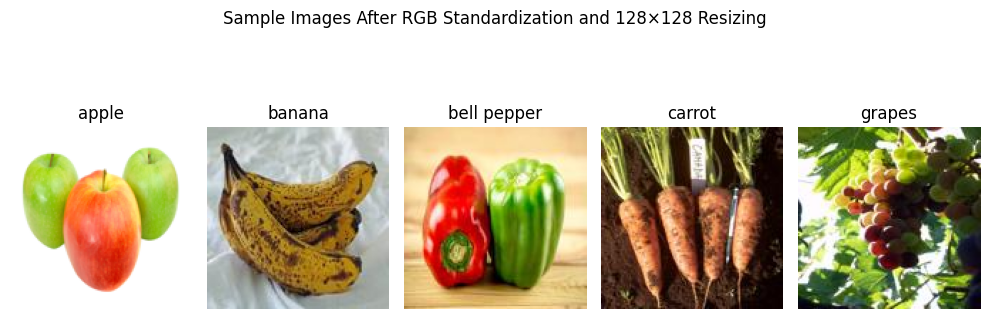

In [ ]:
import os
import matplotlib.pyplot as plt
from PIL import Image

plt.figure(figsize=(10, 4))

shown_images = 0

for class_name in selected_classes[:5]:
    class_path = os.path.join(TRAIN_DIR, class_name)

    if not os.path.exists(class_path):
        print("Folder not found:", class_path)
        continue

    image_files = [
        file for file in os.listdir(class_path)
        if file.lower().endswith(valid_extensions)
    ]

    if len(image_files) == 0:
        print("No image found in:", class_path)
        continue

    sample_image_path = os.path.join(class_path, image_files[0])

    processed_image = Image.open(sample_image_path).convert("RGB")
    processed_image = processed_image.resize((128, 128))

    shown_images += 1

    plt.subplot(1, 5, shown_images)
    plt.imshow(processed_image)
    plt.title(class_name)
    plt.axis("off")

plt.suptitle("Sample Images After RGB Standardization and 128×128 Resizing")
plt.tight_layout()
plt.show()

# Statistical EDA and Preprocessing

## Color Distribution Analysis

In [ ]:
# Step 3: Color Distribution Analysis

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from itertools import combinations


DATASET_DIR = "dataset"   # If your correct path is different, change only this line

TRAIN_DIR = os.path.join(DATASET_DIR, "train")
VAL_DIR = os.path.join(DATASET_DIR, "validation")
TEST_DIR = os.path.join(DATASET_DIR, "test")

selected_classes = [
    "apple",
    "banana",
    "bell pepper",
    "carrot",
    "grapes",
    "kiwi",
    "lemon",
    "orange",
    "pear",
    "tomato"
]

valid_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

# Check paths
print("Train path:", TRAIN_DIR)
print("Available train classes:", os.listdir(TRAIN_DIR))


def calculate_class_rgb_mean(split_dir, class_name, image_size=(128, 128)):
    class_path = os.path.join(split_dir, class_name)

    if not os.path.exists(class_path):
        print("Folder not found:", class_path)
        return np.array([0, 0, 0])

    rgb_means = []

    for file_name in os.listdir(class_path):
        if file_name.lower().endswith(valid_extensions):
            image_path = os.path.join(class_path, file_name)

            with Image.open(image_path) as img:
                img = img.convert("RGB")
                img = img.resize(image_size)
                img_array = np.array(img).astype(np.float32) / 255.0

            mean_rgb = img_array.mean(axis=(0, 1))
            rgb_means.append(mean_rgb)

    if len(rgb_means) == 0:
        print("No images found in:", class_path)
        return np.array([0, 0, 0])

    rgb_means = np.array(rgb_means)

    return rgb_means.mean(axis=0)

rgb_data = []

for class_name in selected_classes:
    mean_r, mean_g, mean_b = calculate_class_rgb_mean(TRAIN_DIR, class_name)

    rgb_data.append({
        "Class": class_name,
        "Mean_R": mean_r,
        "Mean_G": mean_g,
        "Mean_B": mean_b
    })

df_rgb = pd.DataFrame(rgb_data)

df_rgb

Train path: dataset/train
Available train classes: ['apple', 'tomato', 'pear', 'bell pepper', 'carrot', 'lemon', 'kiwi', 'grapes', 'banana', 'orange']


,Class,Mean_R,Mean_G,Mean_B
0,apple,0.647474,0.538996,0.457681
1,banana,0.767899,0.716968,0.487295
2,bell pepper,0.596515,0.541477,0.353613
3,carrot,0.737602,0.605895,0.481471
4,grapes,0.547597,0.551988,0.427819
5,kiwi,0.676315,0.678738,0.481188
6,lemon,0.740254,0.694572,0.426989
7,orange,0.709983,0.547230,0.306266
8,pear,0.693745,0.677309,0.500381
9,tomato,0.605598,0.444425,0.318380


##  Grouped RGB bar chart


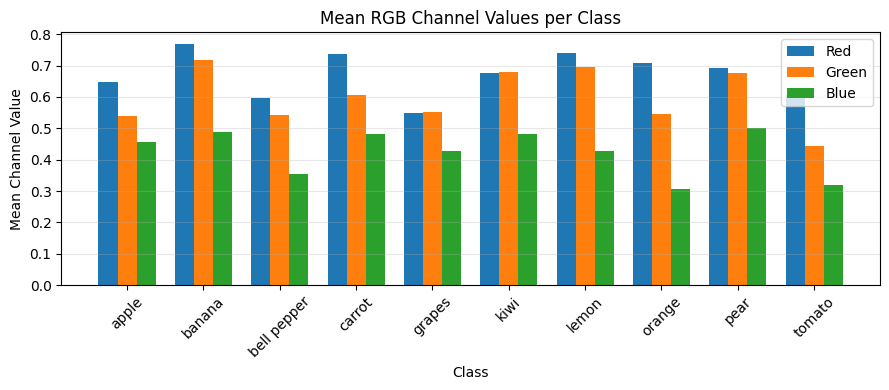

In [ ]:
plt.figure(figsize=(9, 4))

x = np.arange(len(df_rgb["Class"]))
width = 0.25

plt.bar(x - width, df_rgb["Mean_R"], width, label="Red")
plt.bar(x, df_rgb["Mean_G"], width, label="Green")
plt.bar(x + width, df_rgb["Mean_B"], width, label="Blue")

plt.title("Mean RGB Channel Values per Class")
plt.xlabel("Class")
plt.ylabel("Mean Channel Value")
plt.xticks(x, df_rgb["Class"], rotation=45)
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## Pairwise RGB scatter plots


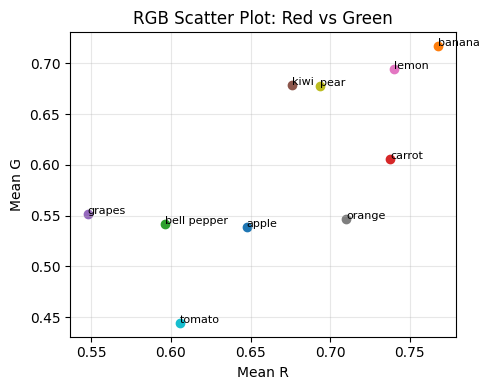

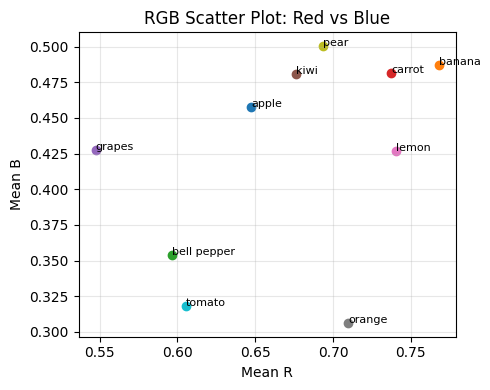

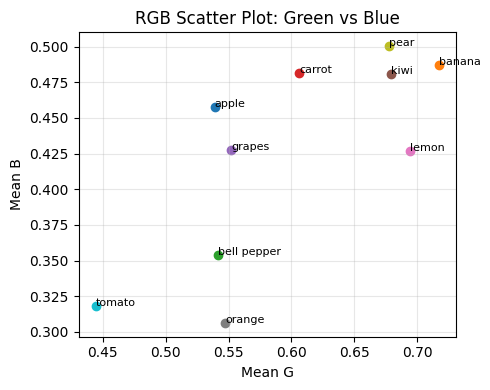

In [ ]:
rgb_pairs = [
    ("Mean_R", "Mean_G", "Red vs Green"),
    ("Mean_R", "Mean_B", "Red vs Blue"),
    ("Mean_G", "Mean_B", "Green vs Blue")
]

for x_col, y_col, title in rgb_pairs:
    plt.figure(figsize=(5, 4))

    for _, row in df_rgb.iterrows():
        plt.scatter(row[x_col], row[y_col])
        plt.text(row[x_col], row[y_col], row["Class"], fontsize=8)

    plt.title(f"RGB Scatter Plot: {title}")
    plt.xlabel(x_col.replace("Mean_", "Mean "))
    plt.ylabel(y_col.replace("Mean_", "Mean "))
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

##  Create RGB distance matrix

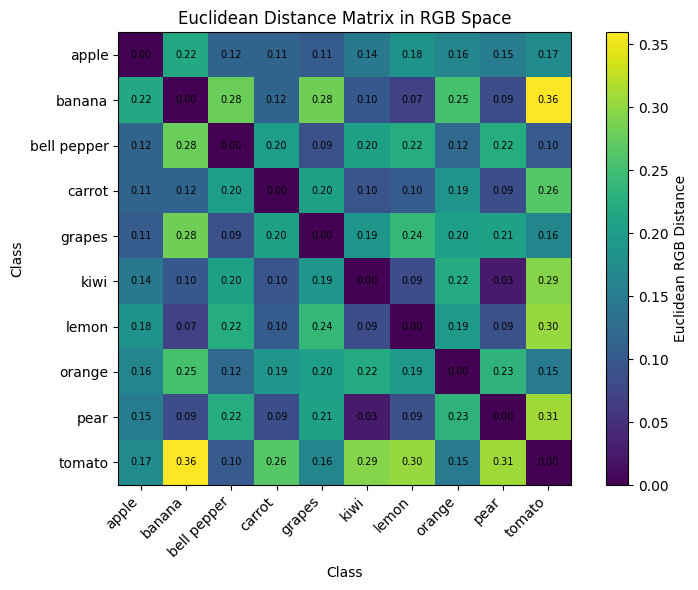

In [ ]:
rgb_values = df_rgb[["Mean_R", "Mean_G", "Mean_B"]].values
class_names = df_rgb["Class"].values

distance_matrix = np.zeros((len(class_names), len(class_names)))

for i in range(len(class_names)):
    for j in range(len(class_names)):
        distance_matrix[i, j] = np.linalg.norm(rgb_values[i] - rgb_values[j])

df_distance = pd.DataFrame(
    distance_matrix,
    index=class_names,
    columns=class_names
)

df_distance


plt.figure(figsize=(8, 6))

plt.imshow(df_distance, cmap="viridis")
plt.colorbar(label="Euclidean RGB Distance")

plt.title("Euclidean Distance Matrix in RGB Space")
plt.xlabel("Class")
plt.ylabel("Class")

plt.xticks(np.arange(len(class_names)), class_names, rotation=45, ha="right")
plt.yticks(np.arange(len(class_names)), class_names)

for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(
            j, i,
            f"{distance_matrix[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=7
        )

plt.tight_layout()
plt.show()

## Find 3 class pairs with highest confusion risk

In [ ]:
pair_distances = []

for i, j in combinations(range(len(class_names)), 2):
    pair_distances.append({
        "Class 1": class_names[i],
        "Class 2": class_names[j],
        "RGB Distance": distance_matrix[i, j]
    })

df_pair_distances = pd.DataFrame(pair_distances)

df_confusion_risk = df_pair_distances.sort_values(
    by="RGB Distance",
    ascending=True
).head(3)

df_confusion_risk

,Class 1,Class 2,RGB Distance
37,kiwi,pear,0.025966
13,banana,lemon,0.070019
15,banana,pear,0.085106


In this step, the average RGB color values were calculated for each selected class using only the training set. The grouped RGB bar chart shows how the red, green, and blue channel values differ between fruit and vegetable classes.

The RGB scatter plots help visualize whether classes form separate color clusters or overlap in color space. Classes that appear close together in these scatter plots may be more difficult for the CNN to distinguish using color alone.

The Euclidean distance matrix was also calculated in RGB space. A smaller distance between two classes means their average colors are more similar. Therefore, the three class pairs with the smallest RGB distances are considered the highest-risk pairs for possible confusion.

Later, these predicted high-risk pairs will be compared with the model’s actual confusion matrix to evaluate whether the initial EDA color analysis correctly predicted the model’s mistakes. 🎯

## Global Normalization ⚖️🖼️

In [ ]:
import os
import numpy as np
from PIL import Image

valid_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".webp")


train_dir = os.path.join(DATASET_DIR, "train")

pixel_sum = np.zeros(3)
pixel_squared_sum = np.zeros(3)
total_pixels = 0

for class_name in selected_classes:
    folder_path = os.path.join(train_dir, class_name)

    for file_name in os.listdir(folder_path):
        if file_name.lower().endswith(valid_extensions):
            image_path = os.path.join(folder_path, file_name)

            with Image.open(image_path) as img:
                img = img.convert("RGB")
                img = img.resize((128, 128))   # safety check
                img_array = np.array(img).astype(np.float32) / 255.0

            pixel_sum += img_array.sum(axis=(0, 1))
            pixel_squared_sum += (img_array ** 2).sum(axis=(0, 1))
            total_pixels += img_array.shape[0] * img_array.shape[1]

train_mean = pixel_sum / total_pixels
train_std = np.sqrt((pixel_squared_sum / total_pixels) - (train_mean ** 2))

print("Training Mean RGB:")
print(f"R: {train_mean[0]:.4f}")
print(f"G: {train_mean[1]:.4f}")
print(f"B: {train_mean[2]:.4f}")

print("\nTraining Standard Deviation RGB:")
print(f"R: {train_std[0]:.4f}")
print(f"G: {train_std[1]:.4f}")
print(f"B: {train_std[2]:.4f}")

Training Mean RGB:
R: 0.6673
G: 0.5984
B: 0.4240

Training Standard Deviation RGB:
R: 0.3092
G: 0.3080
B: 0.3593


## Normalize one sample image as an example


In [ ]:
sample_class = selected_classes[0]
sample_folder = os.path.join(DATASET_DIR, "train", sample_class)

sample_file = [
    file for file in os.listdir(sample_folder)
    if file.lower().endswith(valid_extensions)
][0]

sample_path = os.path.join(sample_folder, sample_file)

image = Image.open(sample_path).convert("RGB")
image_array = np.array(image).astype(np.float32) / 255.0

normalized_image = (image_array - train_mean) / train_std

print("Original image shape:", image_array.shape)
print("Normalized image shape:", normalized_image.shape)

print("\nOriginal pixel range:")
print("Min:", image_array.min())
print("Max:", image_array.max())

print("\nNormalized pixel range:")
print("Min:", normalized_image.min())
print("Max:", normalized_image.max())

Original image shape: (128, 128, 3)
Normalized image shape: (128, 128, 3)

Original pixel range:
Min: 0.0
Max: 1.0

Normalized pixel range:
Min: -1.7518996288881608
Max: 1.603026037207141


##  Function to apply Z-score normalization


In [ ]:
def load_normalized_image(image_path, mean, std):
    with Image.open(image_path) as img:
        img = img.convert("RGB")
        img = img.resize((128, 128))   # safety check
        img_array = np.array(img).astype(np.float32) / 255.0

    normalized_image = (img_array - mean) / std
    return normalized_image

##  Test normalization on all splits without storing all images


In [ ]:
for split in ["train", "validation", "test"]:
    print(f"\nChecking normalization for {split} set...")

    image_count = 0

    for class_name in selected_classes:
        folder_path = os.path.join(DATASET_DIR, split, class_name)

        for file_name in os.listdir(folder_path):
            if file_name.lower().endswith(valid_extensions):
                image_path = os.path.join(folder_path, file_name)

                normalized_image = load_normalized_image(
                    image_path,
                    train_mean,
                    train_std
                )

                image_count += 1

    print(f"{split} set normalized successfully.")
    print(f"Number of images checked: {image_count}")
    print(f"Example normalized image shape: {normalized_image.shape}")


Checking normalization for train set...
train set normalized successfully.
Number of images checked: 835
Example normalized image shape: (128, 128, 3)

Checking normalization for validation set...
validation set normalized successfully.
Number of images checked: 95
Example normalized image shape: (128, 128, 3)

Checking normalization for test set...
test set normalized successfully.
Number of images checked: 99
Example normalized image shape: (128, 128, 3)


The mean and standard deviation for the Red, Green, and Blue channels were calculated using only the training set. These values were then used to apply Z-score normalization to the Train, Validation, and Test sets.

The normalization formula is:

X normalized  =   x−μ   /  σ
	​

    
The Test Set was not used to calculate the normalization statistics because this would cause data leakage. The Test Set must represent unseen data, so using its pixel statistics during preprocessing would give indirect information about the evaluation data. Therefore, only Training Set statistics were used

## Training-Only Data Augmentation Pipeline 🔄🖼️

In [ ]:
import os
import matplotlib.pyplot as plt
from PIL import Image, ImageEnhance, ImageDraw

train_dir = os.path.join(DATASET_DIR, "train")
valid_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

def augment_image(image, i):
    image = image.convert("RGB")

    angles = [-15, -8, 5, 10, 15]
    image = image.rotate(angles[i % 5])

    if i % 2 == 0:
        image = image.transpose(Image.FLIP_LEFT_RIGHT)

    brightness_values = [0.8, 0.9, 1.1, 1.2, 1.0]
    image = ImageEnhance.Brightness(image).enhance(brightness_values[i % 5])

    contrast_values = [1.2, 1.1, 0.9, 0.8, 1.0]
    image = ImageEnhance.Contrast(image).enhance(contrast_values[i % 5])

    draw = ImageDraw.Draw(image)
    x = 20 + i * 10
    y = 25 + i * 8
    draw.rectangle([x, y, x + 25, y + 25], fill=(0, 0, 0))

    return image


sample_images = []
sample_labels = []

for class_name in selected_classes:
    folder_path = os.path.join(train_dir, class_name)

    image_files = [
        file for file in os.listdir(folder_path)
        if file.lower().endswith(valid_extensions)
    ]

    image_path = os.path.join(folder_path, image_files[0])
    image = Image.open(image_path).convert("RGB")

    sample_images.append(image)
    sample_labels.append(class_name)

    if len(sample_images) == 5:
        break

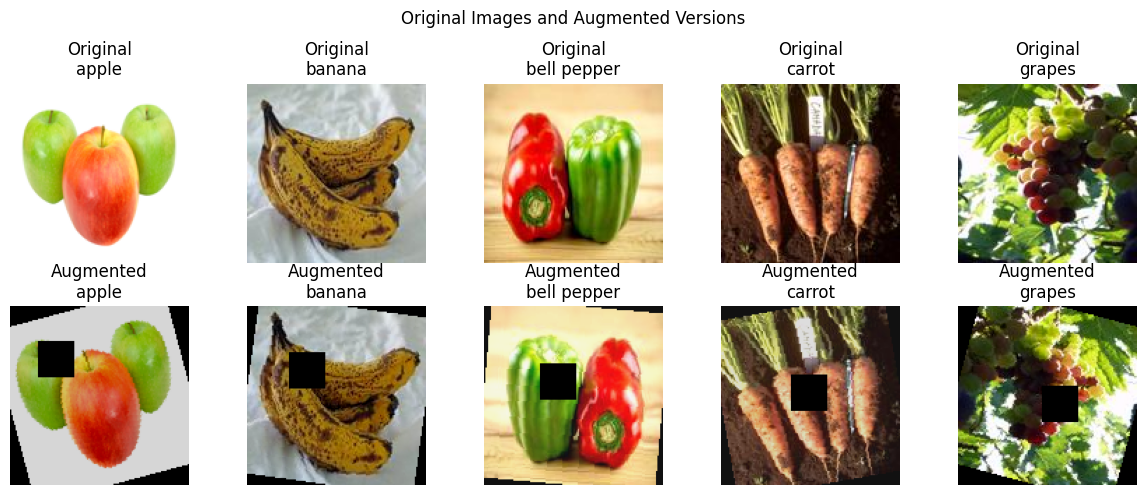

In [28]:
plt.figure(figsize=(12, 5))

for i in range(5):
    original_image = sample_images[i]
    augmented_image = augment_image(original_image, i)

    plt.subplot(2, 5, i + 1)
    plt.imshow(original_image)
    plt.title(f"Original\n{sample_labels[i]}")
    plt.axis("off")

    plt.subplot(2, 5, i + 6)
    plt.imshow(augmented_image)
    plt.title(f"Augmented\n{sample_labels[i]}")
    plt.axis("off")

plt.suptitle("Original Images and Augmented Versions")
plt.tight_layout()
plt.show()

A training-only data augmentation pipeline was created to improve model robustness and reduce overfitting. The pipeline includes random rotation up to 15 degrees, random horizontal flipping, brightness and contrast jitter, and optional cutout using random erasing.

These transformations are applied only to the training set. Validation and test images are not augmented because they must represent real unseen data. This keeps the evaluation fair and prevents artificial changes from affecting validation or test results.

## Prepare Data Generators for CNN Training 🧠📁

In [29]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

In [ ]:
train_dir = os.path.join(DATASET_DIR, "train")
val_dir = os.path.join(DATASET_DIR, "validation")
test_dir = os.path.join(DATASET_DIR, "test")

IMAGE_SIZE = (128, 128)
BATCH_SIZE = 32
NUM_CLASSES = len(selected_classes)

print("Number of classes:", NUM_CLASSES)
print("Classes:", selected_classes)

Number of classes: 10
Classes: ['apple', 'banana', 'bell pepper', 'carrot', 'grapes', 'kiwi', 'lemon', 'orange', 'pear', 'tomato']


## Normalization functions

In [ ]:
train_mean = np.array(train_mean)
train_std = np.array(train_std)

def normalize_only(image):
    image = image / 255.0
    image = (image - train_mean) / train_std
    return image


def train_preprocess(image):

    contrast_factor = np.random.uniform(0.8, 1.2)
    mean_pixel = np.mean(image, axis=(0, 1), keepdims=True)
    image = (image - mean_pixel) * contrast_factor + mean_pixel
    image = np.clip(image, 0, 255)

    if np.random.rand() < 0.3:
        h, w, c = image.shape
        cutout_size = np.random.randint(15, 35)

        x = np.random.randint(0, w - cutout_size)
        y = np.random.randint(0, h - cutout_size)

        image[y:y + cutout_size, x:x + cutout_size, :] = 0

    image = image / 255.0
    image = (image - train_mean) / train_std

    return image

## Training-only augmentation

In [ ]:
train_datagen = ImageDataGenerator(
    rotation_range=15,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    preprocessing_function=train_preprocess
)

val_test_datagen = ImageDataGenerator(
    preprocessing_function=normalize_only
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    classes=selected_classes,
    class_mode="sparse",
    shuffle=True
)

val_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    classes=selected_classes,
    class_mode="sparse",
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    classes=selected_classes,
    class_mode="sparse",
    shuffle=False
)

Found 835 images belonging to 10 classes.
Found 95 images belonging to 10 classes.
Found 99 images belonging to 10 classes.


## CNN Model Architecture

In [ ]:
def build_cnn_model(input_shape=(128, 128, 3), num_classes=10):
    model = models.Sequential(name="Fruit_Vegetable_CNN")

    # Block 1: 32 filters
    model.add(layers.Conv2D(32, (3, 3), padding="same", input_shape=input_shape))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    model.add(layers.MaxPooling2D((2, 2)))

    # Block 2: 64 filters
    model.add(layers.Conv2D(64, (3, 3), padding="same"))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    model.add(layers.MaxPooling2D((2, 2)))

    # Block 3: 128 filters
    model.add(layers.Conv2D(128, (3, 3), padding="same"))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    model.add(layers.MaxPooling2D((2, 2)))

    # Block 4: 256 filters
    model.add(layers.Conv2D(256, (3, 3), padding="same"))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    model.add(layers.MaxPooling2D((2, 2)))

    # Classifier Head
    model.add(layers.GlobalAveragePooling2D())
    model.add(layers.Dropout(0.3))
    model.add(layers.Dense(num_classes, activation="softmax"))

    return model


model = build_cnn_model(
    input_shape=(128, 128, 3),
    num_classes=NUM_CLASSES
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Fruit_Vegetable_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 392,906 (1.50 MB)

 Trainable params: 391,946 (1.50 MB)

 Non-trainable params: 960 (3.75 KB)

Short Report

A modular CNN model was created using four convolutional blocks. Each block follows the required structure:

Conv2D→BatchNormalization→ReLU→MaxPooling2D

The number of filters starts at 32 and doubles in each block:

32→64→128→256

The classifier uses Global Average Pooling instead of Flatten. GAP reduces the number of trainable parameters and helps reduce overfitting because it summarizes each feature map instead of creating a very large flattened vector.

## Compile model

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

## Train the Model with Early Stopping and LR Scheduler ⏱️

In [ ]:
class TrainingLogger(tf.keras.callbacks.Callback):
    def on_train_begin(self, logs=None):
        self.epoch_times = []
        self.learning_rates = []

    def on_epoch_begin(self, epoch, logs=None):
        self.start_time = time.time()

    def on_epoch_end(self, epoch, logs=None):
        epoch_time = time.time() - self.start_time
        self.epoch_times.append(epoch_time)

        lr = float(tf.keras.backend.get_value(self.model.optimizer.learning_rate))
        self.learning_rates.append(lr)


training_logger = TrainingLogger()

In [ ]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    patience=3,
    factor=0.5,
    verbose=1
)

In [37]:
import time

## Train model

In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=50,
    callbacks=[
        early_stopping,
        lr_scheduler,
        training_logger
    ]
)

Epoch 1/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 22s 461ms/step - accuracy: 0.3174 - loss: 2.0384 - val_accuracy: 0.3368 - val_loss: 1.9930 - learning_rate: 0.0010
Epoch 2/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 7s 241ms/step - accuracy: 0.4443 - loss: 1.5839 - val_accuracy: 0.3579 - val_loss: 1.8193 - learning_rate: 0.0010
Epoch 3/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 6s 204ms/step - accuracy: 0.4695 - loss: 1.5413 - val_accuracy: 0.5053 - val_loss: 1.4616 - learning_rate: 0.0010
Epoch 4/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 6s 240ms/step - accuracy: 0.5150 - loss: 1.3935 - val_accuracy: 0.5053 - val_loss: 1.5023 - learning_rate: 0.0010
Epoch 5/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 198ms/step - accuracy: 0.5449 - loss: 1.3314 - val_accuracy: 0.3368 - val_loss: 1.7692 - learning_rate: 0.0010
Epoch 6/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 6s 233ms/step - accuracy: 0.5473 - loss: 1.2889 - val_accuracy: 0.6211 - val_loss: 1.2451 - learning_rate: 0.0010
Epoch 7/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 194ms/step - accuracy: 0.5533 - loss: 1.3883 -

In [ ]:
average_epoch_time = np.mean(training_logger.epoch_times)

print("Average training time per epoch:", round(average_epoch_time, 2), "seconds")
print("Total epochs trained:", len(training_logger.epoch_times))

Average training time per epoch: 6.71 seconds
Total epochs trained: 29


## Find LR scheduler activation epochs


In [ ]:
learning_rates = training_logger.learning_rates

lr_change_epochs = []

for i in range(1, len(learning_rates)):
    if learning_rates[i] < learning_rates[i - 1]:
        lr_change_epochs.append(i + 1)

print("Learning rates per epoch:")
print(learning_rates)

print("\nLR scheduler activated at epochs:")
print(lr_change_epochs)

Learning rates per epoch:
[0.0010000000474974513, 0.0010000000474974513, 0.0010000000474974513, 0.0010000000474974513, 0.0010000000474974513, 0.0010000000474974513, 0.0010000000474974513, 0.0010000000474974513, 0.0010000000474974513, 0.0010000000474974513, 0.0010000000474974513, 0.0010000000474974513, 0.0010000000474974513, 0.0010000000474974513, 0.0005000000237487257, 0.0005000000237487257, 0.0005000000237487257, 0.0005000000237487257, 0.0005000000237487257, 0.0005000000237487257, 0.0005000000237487257, 0.0002500000118743628, 0.0002500000118743628, 0.0002500000118743628, 0.0002500000118743628, 0.0002500000118743628, 0.0001250000059371814, 0.0001250000059371814, 0.0001250000059371814]

LR scheduler activated at epochs:
[15, 22, 27]


Short Report

The CNN was trained for a maximum of 50 epochs using Early Stopping and ReduceLROnPlateau. Early Stopping monitored validation loss with a patience of 5 epochs, while the learning rate scheduler reduced the learning rate by a factor of 0.5 when validation loss stopped improving for 3 epochs.

The average training time per epoch was also recorded. The epochs where the learning rate scheduler activated were identified by checking when the learning rate decreased during training.

## Plot Training and Validation Curves 📈

In [ ]:
train_loss = history.history["loss"]
val_loss = history.history["val_loss"]

train_acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]

epochs_range = range(1, len(train_loss) + 1)

best_epoch = np.argmin(val_loss) + 1
final_epoch = len(train_loss)

print("Best epoch based on validation loss:", best_epoch)
print("Final training epoch:", final_epoch)

Best epoch based on validation loss: 24
Final training epoch: 29


## Plot loss curves

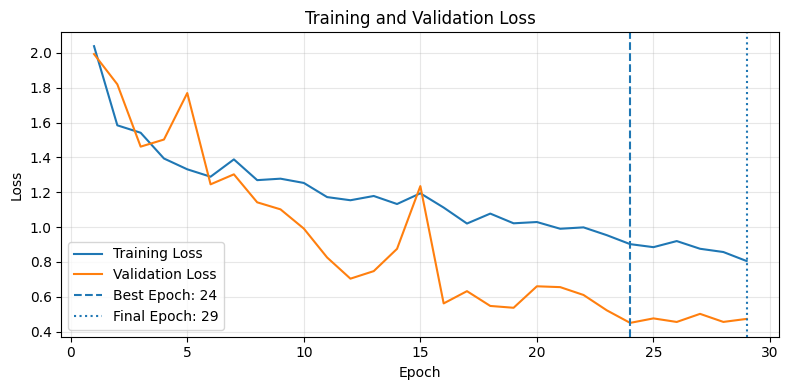

In [ ]:
plt.figure(figsize=(8, 4))

plt.plot(epochs_range, train_loss, label="Training Loss")
plt.plot(epochs_range, val_loss, label="Validation Loss")

plt.axvline(best_epoch, linestyle="--", label=f"Best Epoch: {best_epoch}")
plt.axvline(final_epoch, linestyle=":", label=f"Final Epoch: {final_epoch}")

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Plot accuracy curves

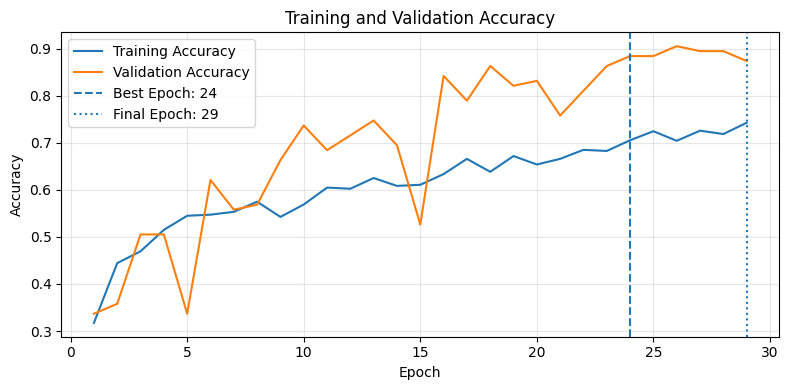

In [ ]:
plt.figure(figsize=(8, 4))

plt.plot(epochs_range, train_acc, label="Training Accuracy")
plt.plot(epochs_range, val_acc, label="Validation Accuracy")

plt.axvline(best_epoch, linestyle="--", label=f"Best Epoch: {best_epoch}")
plt.axvline(final_epoch, linestyle=":", label=f"Final Epoch: {final_epoch}")

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Plot learning rate changes

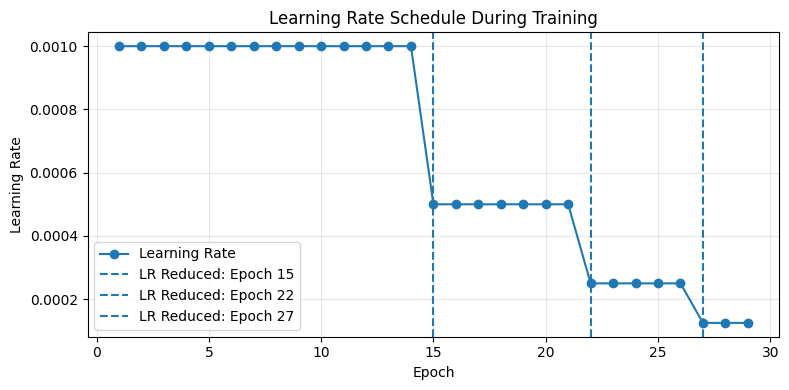

In [ ]:
plt.figure(figsize=(8, 4))

plt.plot(epochs_range, learning_rates, marker="o", label="Learning Rate")

for epoch in lr_change_epochs:
    plt.axvline(epoch, linestyle="--", label=f"LR Reduced: Epoch {epoch}")

plt.title("Learning Rate Schedule During Training")
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Training and validation loss and accuracy were plotted across epochs. The best epoch was identified using the lowest validation loss, and the final training epoch was marked to show where training stopped. The learning rate curve was also plotted to show when ReduceLROnPlateau activated.

These curves help identify whether the model overfitted. Overfitting is suggested when training loss continues decreasing while validation loss increases, or when training accuracy keeps improving while validation accuracy stops improving or decreases.

## Load Test Images for Robustness Analysis

In [45]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

TEST_DIR = os.path.join(DATASET_DIR, "test")
IMAGE_SIZE = (128, 128)
valid_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

X_test = []
y_test = []

for class_index, class_name in enumerate(selected_classes):
    folder_path = os.path.join(TEST_DIR, class_name)

    for file_name in os.listdir(folder_path):
        if file_name.lower().endswith(valid_extensions):
            image_path = os.path.join(folder_path, file_name)

            image = Image.open(image_path).convert("RGB")
            image = image.resize(IMAGE_SIZE)

            image_array = np.array(image).astype(np.float32) / 255.0

            X_test.append(image_array)
            y_test.append(class_index)

X_test = np.array(X_test)
y_test = np.array(y_test)

print("Test images shape:", X_test.shape)
print("Test labels shape:", y_test.shape)

Test images shape: (99, 128, 128, 3)
Test labels shape: (99,)


Short Report

In this step, all test images were loaded from the original test folder. Each image was converted to RGB, resized to 128×128, and converted into a NumPy array. The labels were stored as class indices for model evaluation.

## Define Robustness Transformations

In [46]:
def normalize_images(images):
    return (images - train_mean) / train_std


def make_grayscale(images):
    gray = np.mean(images, axis=3, keepdims=True)
    gray_3_channels = np.repeat(gray, 3, axis=3)
    return gray_3_channels


def swap_red_blue(images):
    swapped = images.copy()
    swapped[:, :, :, [0, 2]] = swapped[:, :, :, [2, 0]]
    return swapped


def add_gaussian_noise(images, sigma=0.1):
    noise = np.random.normal(0, sigma, images.shape)
    noisy_images = images + noise
    noisy_images = np.clip(noisy_images, 0, 1)
    return noisy_images

Short Report

Four test scenarios were prepared. The baseline uses the original RGB images. The grayscale test removes color information to evaluate whether the model depends on shape. The channel-swap test exchanges the red and blue channels to test color sensitivity. The noise test adds Gaussian noise to evaluate robustness against visual corruption.

## Load Test Images for Robustness Analysis

In [47]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

TEST_DIR = os.path.join(DATASET_DIR, "test")
IMAGE_SIZE = (128, 128)
valid_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

X_test = []
y_test = []

for class_index, class_name in enumerate(selected_classes):
    folder_path = os.path.join(TEST_DIR, class_name)

    for file_name in os.listdir(folder_path):
        if file_name.lower().endswith(valid_extensions):
            image_path = os.path.join(folder_path, file_name)

            image = Image.open(image_path).convert("RGB")
            image = image.resize(IMAGE_SIZE)

            image_array = np.array(image).astype(np.float32) / 255.0

            X_test.append(image_array)
            y_test.append(class_index)

X_test = np.array(X_test)
y_test = np.array(y_test)

print("Test images shape:", X_test.shape)
print("Test labels shape:", y_test.shape)

Test images shape: (99, 128, 128, 3)
Test labels shape: (99,)


## Define Robustness Transformations

In [48]:
def normalize_images(images):
    return (images - train_mean) / train_std


def make_grayscale(images):
    gray = np.mean(images, axis=3, keepdims=True)
    gray_3_channels = np.repeat(gray, 3, axis=3)
    return gray_3_channels


def swap_red_blue(images):
    swapped = images.copy()
    swapped[:, :, :, [0, 2]] = swapped[:, :, :, [2, 0]]
    return swapped


def add_gaussian_noise(images, sigma=0.1):
    noise = np.random.normal(0, sigma, images.shape)
    noisy_images = images + noise
    noisy_images = np.clip(noisy_images, 0, 1)
    return noisy_images

## Evaluate Baseline, Grayscale, Channel Swap, and Noise Scenarios

In [49]:
def evaluate_scenario(images, y_true, scenario_name):
    images_normalized = normalize_images(images)

    predictions = model.predict(images_normalized)
    y_pred = np.argmax(predictions, axis=1)

    accuracy = accuracy_score(y_true, y_pred)

    print(f"\n===== {scenario_name} =====")
    print("Accuracy:", round(accuracy, 4))
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=selected_classes))

    return accuracy, y_pred


# Scenario A: Baseline RGB
acc_baseline, pred_baseline = evaluate_scenario(
    X_test,
    y_test,
    "Scenario A — Baseline RGB"
)

# Scenario B: Grayscale
X_test_gray = make_grayscale(X_test)

acc_gray, pred_gray = evaluate_scenario(
    X_test_gray,
    y_test,
    "Scenario B — Grayscale"
)

# Scenario C: Red/Blue Channel Swap
X_test_swap = swap_red_blue(X_test)

acc_swap, pred_swap = evaluate_scenario(
    X_test_swap,
    y_test,
    "Scenario C — Red/Blue Channel Swap"
)

# Scenario D: Gaussian Noise
X_test_noise = add_gaussian_noise(X_test, sigma=0.1)

acc_noise, pred_noise = evaluate_scenario(
    X_test_noise,
    y_test,
    "Scenario D — Gaussian Noise"
)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 179ms/step

===== Scenario A — Baseline RGB =====
Accuracy: 0.8889

Classification Report:
              precision    recall  f1-score   support

       apple       0.78      0.70      0.74        10
      banana       1.00      0.78      0.88         9
 bell pepper       0.89      0.80      0.84        10
      carrot       1.00      1.00      1.00        10
      grapes       1.00      1.00      1.00        10
        kiwi       1.00      0.90      0.95        10
       lemon       0.82      0.90      0.86        10
      orange       0.82      0.90      0.86        10
        pear       0.83      1.00      0.91        10
      tomato       0.82      0.90      0.86        10

    accuracy                           0.89        99
   macro avg       0.90      0.89      0.89        99
weighted avg       0.89      0.89      0.89        99

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step

===== Scenario B — Grayscale =====
Accuracy: 0.1414

Classification Report:
       

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step

===== Scenario C — Red/Blue Channel Swap =====
Accuracy: 0.2525

Classification Report:
              precision    recall  f1-score   support

       apple       0.00      0.00      0.00        10
      banana       0.00      0.00      0.00         9
 bell pepper       0.00      0.00      0.00        10
      carrot       0.00      0.00      0.00        10
      grapes       0.17      0.80      0.28        10
        kiwi       0.00      0.00      0.00        10
       lemon       0.42      0.80      0.55        10
      orange       0.00      0.00      0.00        10
        pear       0.33      0.90      0.49        10
      tomato       0.00      0.00      0.00        10

    accuracy                           0.25        99
   macro avg       0.09      0.25      0.13        99
weighted avg       0.09      0.25      0.13        99



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step

===== Scenario D — Gaussian Noise =====
Accuracy: 0.5657

Classification Report:
              precision    recall  f1-score   support

       apple       0.55      0.60      0.57        10
      banana       0.00      0.00      0.00         9
 bell pepper       1.00      0.30      0.46        10
      carrot       0.35      0.90      0.50        10
      grapes       0.60      0.90      0.72        10
        kiwi       1.00      0.10      0.18        10
       lemon       0.71      0.50      0.59        10
      orange       0.50      1.00      0.67        10
        pear       0.80      0.80      0.80        10
      tomato       0.83      0.50      0.62        10

    accuracy                           0.57        99
   macro avg       0.63      0.56      0.51        99
weighted avg       0.64      0.57      0.52        99



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Plot Normalized Confusion Matrices

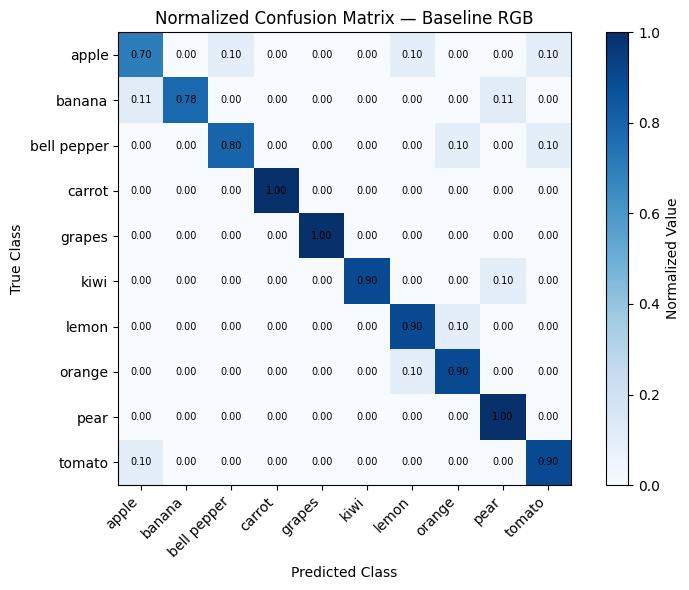

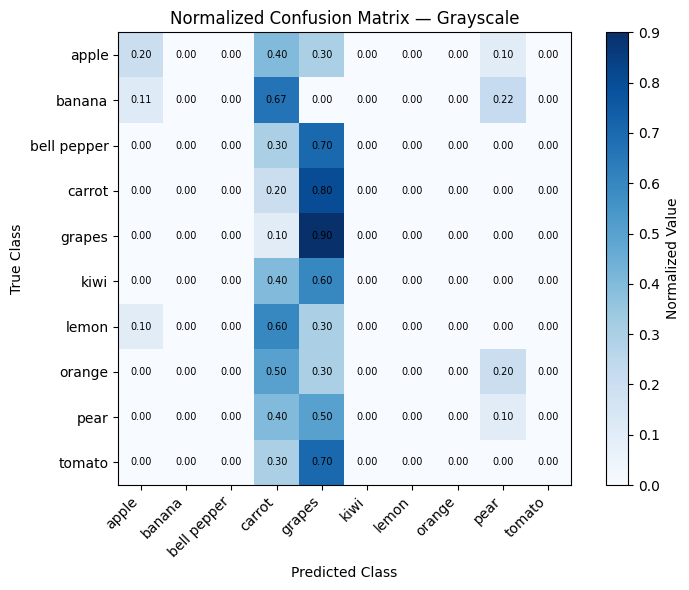

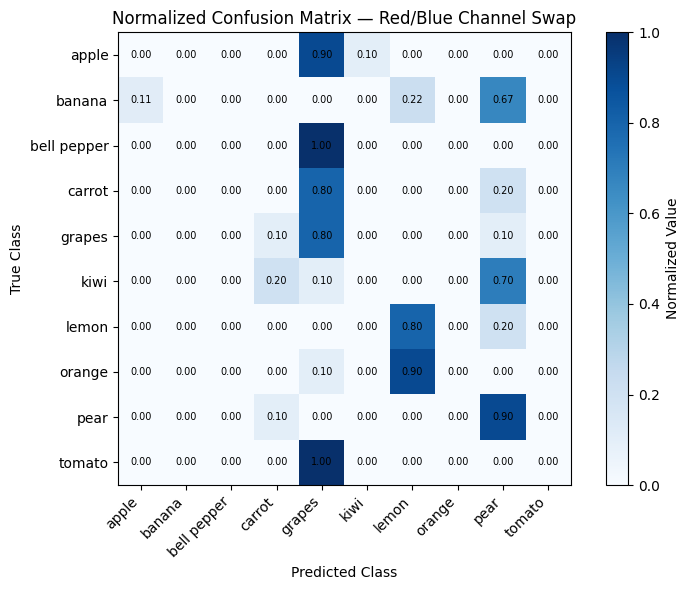

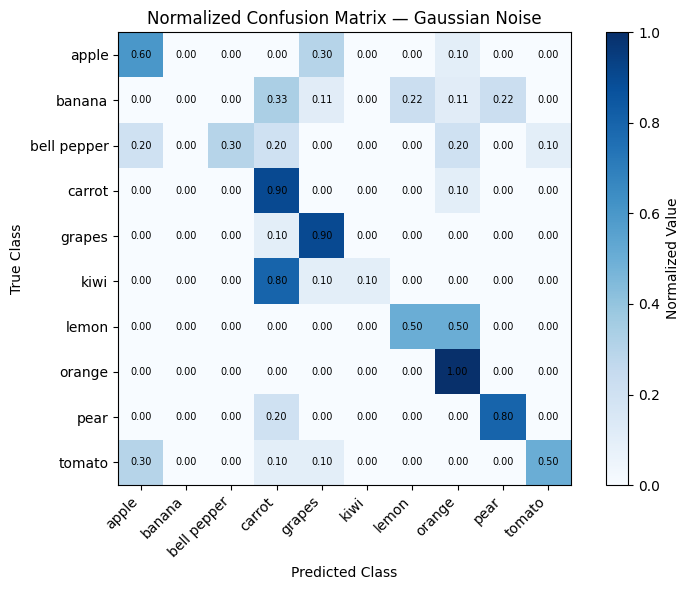

In [50]:
def plot_normalized_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)

    cm_normalized = cm.astype("float") / cm.sum(axis=1, keepdims=True)

    plt.figure(figsize=(8, 6))
    plt.imshow(cm_normalized, cmap="Blues")
    plt.colorbar(label="Normalized Value")

    plt.title(title)
    plt.xlabel("Predicted Class")
    plt.ylabel("True Class")

    plt.xticks(np.arange(len(selected_classes)), selected_classes, rotation=45, ha="right")
    plt.yticks(np.arange(len(selected_classes)), selected_classes)

    for i in range(len(selected_classes)):
        for j in range(len(selected_classes)):
            plt.text(j, i, f"{cm_normalized[i, j]:.2f}",
                     ha="center", va="center", fontsize=7)

    plt.tight_layout()
    plt.show()


plot_normalized_confusion_matrix(
    y_test,
    pred_baseline,
    "Normalized Confusion Matrix — Baseline RGB"
)

plot_normalized_confusion_matrix(
    y_test,
    pred_gray,
    "Normalized Confusion Matrix — Grayscale"
)

plot_normalized_confusion_matrix(
    y_test,
    pred_swap,
    "Normalized Confusion Matrix — Red/Blue Channel Swap"
)

plot_normalized_confusion_matrix(
    y_test,
    pred_noise,
    "Normalized Confusion Matrix — Gaussian Noise"
)

## Create Robustness Comparison Table

In [51]:
def get_biggest_drop_class(y_true, pred_baseline, pred_scenario):
    drops = []

    for class_index, class_name in enumerate(selected_classes):
        class_mask = y_true == class_index

        baseline_class_acc = accuracy_score(
            y_true[class_mask],
            pred_baseline[class_mask]
        )

        scenario_class_acc = accuracy_score(
            y_true[class_mask],
            pred_scenario[class_mask]
        )

        drop = baseline_class_acc - scenario_class_acc

        drops.append({
            "Class": class_name,
            "Drop": drop
        })

    drops_df = pd.DataFrame(drops)
    biggest_drop = drops_df.sort_values(by="Drop", ascending=False).iloc[0]

    return biggest_drop["Class"], biggest_drop["Drop"]


def get_most_confused_pair(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)

    np.fill_diagonal(cm, 0)

    max_index = np.unravel_index(np.argmax(cm), cm.shape)

    true_class = selected_classes[max_index[0]]
    predicted_class = selected_classes[max_index[1]]

    return f"{true_class} → {predicted_class}"


results = []

scenarios = [
    ("A — Baseline", acc_baseline, pred_baseline),
    ("B — Grayscale", acc_gray, pred_gray),
    ("C — Channel Swap", acc_swap, pred_swap),
    ("D — Noise", acc_noise, pred_noise)
]

for scenario_name, scenario_acc, scenario_pred in scenarios:
    accuracy_drop = acc_baseline - scenario_acc

    if scenario_name == "A — Baseline":
        biggest_drop_class = "-"
        biggest_drop_value = "-"
    else:
        biggest_drop_class, biggest_drop_value = get_biggest_drop_class(
            y_test,
            pred_baseline,
            scenario_pred
        )

    most_confused_pair = get_most_confused_pair(y_test, scenario_pred)

    results.append({
        "Scenario": scenario_name,
        "Overall Accuracy": round(scenario_acc, 4),
        "Accuracy Drop": "-" if scenario_name == "A — Baseline" else round(accuracy_drop, 4),
        "Biggest Drop Class": biggest_drop_class,
        "Most Confused Pair": most_confused_pair
    })

df_robustness = pd.DataFrame(results)

df_robustness

,Scenario,Overall Accuracy,Accuracy Drop,Biggest Drop Class,Most Confused Pair
0,A — Baseline,0.8889,-,-,apple → bell pepper
1,B — Grayscale,0.1414,0.7475,pear,carrot → grapes
2,C — Channel Swap,0.2525,0.6364,carrot,bell pepper → grapes
3,D — Noise,0.5657,0.3232,kiwi,kiwi → carrot


The scenario that caused the greatest accuracy drop was [write scenario name], with an accuracy drop of [write value]. This indicates that the model was most sensitive to this type of visual change.

If the Grayscale scenario caused a large drop, this suggests that the model relied strongly on color information. If the accuracy remained relatively high in grayscale, this suggests that the model learned shape, texture, and structural features in addition to color.

The most confused class pair was [write pair]. This result should be compared with the RGB distance matrix from the EDA section. If classes with low RGB distance also showed high confusion, then the EDA successfully predicted color-based confusion risk.

For machine vision systems in low-light environments or monochrome cameras, the model should not rely only on color. More grayscale augmentation, stronger shape-based training, background removal, and texture-focused preprocessing may improve robustness.

## Find Correct and Incorrect Predictions for Grad-CAM 🔍

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

X_test_normalized = normalize_images(X_test)

pred_probs = model.predict(X_test_normalized)
y_pred = np.argmax(pred_probs, axis=1)

correct_indices = np.where(y_pred == y_test)[0]
incorrect_indices = np.where(y_pred != y_test)[0]

print("Number of correct predictions:", len(correct_indices))
print("Number of incorrect predictions:", len(incorrect_indices))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Number of correct predictions: 88
Number of incorrect predictions: 11


## Select 2 Correct and 2 Incorrect Images from Different Classes

In [53]:
def select_different_classes(indices, y_true, number_needed=2):
    selected = []
    used_classes = set()

    for idx in indices:
        class_id = y_true[idx]

        if class_id not in used_classes:
            selected.append(idx)
            used_classes.add(class_id)

        if len(selected) == number_needed:
            break

    return selected


selected_correct = select_different_classes(correct_indices, y_test, number_needed=2)
selected_incorrect = select_different_classes(incorrect_indices, y_test, number_needed=2)

print("Selected correct indices:", selected_correct)
print("Selected incorrect indices:", selected_incorrect)

Selected correct indices: [np.int64(0), np.int64(10)]
Selected incorrect indices: [np.int64(5), np.int64(11)]


## Grad-CAM Function for Final Convolutional Layer

In [ ]:
last_conv_layer_name = None

for layer in reversed(model.layers):
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv_layer_name = layer.name
        break

print("Last convolutional layer:", last_conv_layer_name)

Last convolutional layer: conv2d_3


In [ ]:
def make_gradcam_heatmap(image_array, model, last_conv_layer_name):
    
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[
            model.get_layer(last_conv_layer_name).output,
            model.output
        ]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(image_array)
        predicted_class = tf.argmax(predictions[0])
        class_score = predictions[:, predicted_class]

    gradients = tape.gradient(class_score, conv_outputs)

    pooled_gradients = tf.reduce_mean(gradients, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_gradients[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0)

    if tf.reduce_max(heatmap) != 0:
        heatmap = heatmap / tf.reduce_max(heatmap)

    return heatmap.numpy(), int(predicted_class.numpy())

## Overlay Grad-CAM Heatmap on Original Image

In [ ]:
def overlay_heatmap(original_image, heatmap, alpha=0.4):
    
    heatmap_resized = tf.image.resize(
        heatmap[..., np.newaxis],
        (original_image.shape[0], original_image.shape[1])
    ).numpy()

    heatmap_resized = np.squeeze(heatmap_resized)

    cmap = plt.get_cmap("jet")
    heatmap_colored = cmap(heatmap_resized)[:, :, :3]

    overlay = heatmap_colored * alpha + original_image * (1 - alpha)
    overlay = np.clip(overlay, 0, 1)

    return overlay

## Display Grad-CAM for Correct and Incorrect Predictions

In [57]:
def show_gradcam_examples(indices, title):
    if len(indices) == 0:
        print("No images found for:", title)
        return

    n = len(indices)

    plt.figure(figsize=(5 * n, 5))

    for i, idx in enumerate(indices):
        original_image = X_test[idx]

        # Normalize image before prediction
        input_image = normalize_images(original_image[np.newaxis, ...])

        heatmap, predicted_class = make_gradcam_heatmap(
            input_image,
            model,
            last_conv_layer_name
        )

        overlay = overlay_heatmap(original_image, heatmap)

        true_label = selected_classes[int(y_test[idx])]
        predicted_label = selected_classes[int(predicted_class)]

        # Original image
        plt.subplot(2, n, i + 1)
        plt.imshow(original_image)
        plt.title(f"Original\nTrue: {true_label}")
        plt.xlabel("Width")
        plt.ylabel("Height")
        plt.xticks([])
        plt.yticks([])

        # Grad-CAM overlay image
        plt.subplot(2, n, i + 1 + n)
        plt.imshow(overlay)
        plt.title(f"Grad-CAM\nPred: {predicted_label}")
        plt.xlabel("Width")
        plt.ylabel("Height")
        plt.xticks([])
        plt.yticks([])

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

## Grad-CAM Comparison: Color vs Grayscale Scenario

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np


inputs = tf.keras.Input(shape=(128, 128, 3))

x = layers.Conv2D(32, (3, 3), padding="same", name="conv1")(inputs)
x = layers.BatchNormalization(name="bn1")(x)
x = layers.ReLU(name="relu1")(x)
x = layers.MaxPooling2D((2, 2), name="pool1")(x)

x = layers.Conv2D(64, (3, 3), padding="same", name="conv2")(x)
x = layers.BatchNormalization(name="bn2")(x)
x = layers.ReLU(name="relu2")(x)
x = layers.MaxPooling2D((2, 2), name="pool2")(x)

x = layers.Conv2D(128, (3, 3), padding="same", name="conv3")(x)
x = layers.BatchNormalization(name="bn3")(x)
x = layers.ReLU(name="relu3")(x)
x = layers.MaxPooling2D((2, 2), name="pool3")(x)

x = layers.Conv2D(256, (3, 3), padding="same", name="conv4")(x)
x = layers.BatchNormalization(name="bn4")(x)
x = layers.ReLU(name="relu4")(x)

last_conv_output = x

x = layers.MaxPooling2D((2, 2), name="pool4")(x)
x = layers.GlobalAveragePooling2D(name="gap")(x)
x = layers.Dropout(0.3, name="dropout")(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax", name="classifier")(x)

gradcam_model_base = tf.keras.Model(inputs=inputs, outputs=outputs)

gradcam_model_base.set_weights(model.get_weights())

print("Functional Grad-CAM model created successfully.")

last_conv_layer_name = "conv4"

def make_gradcam_heatmap(image_array, model, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        inputs=model.input,
        outputs=[
            model.get_layer(last_conv_layer_name).output,
            model.output
        ]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(image_array)
        predicted_class = tf.argmax(predictions[0])
        class_score = predictions[:, predicted_class]

    gradients = tape.gradient(class_score, conv_outputs)

    pooled_gradients = tf.reduce_mean(gradients, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_gradients[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0)

    max_value = tf.reduce_max(heatmap)

    if max_value != 0:
        heatmap = heatmap / max_value

    return heatmap.numpy(), int(predicted_class.numpy())

Functional Grad-CAM model created successfully.


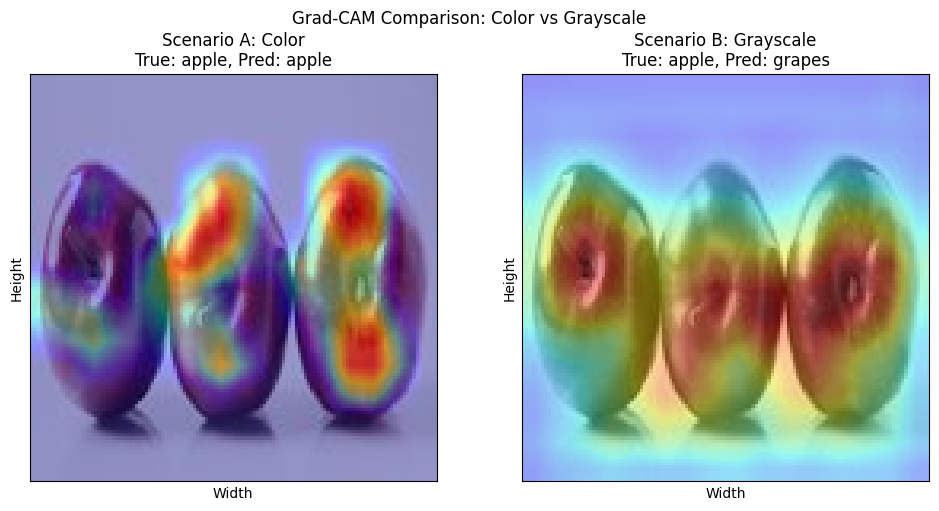

In [ ]:
comparison_index = selected_correct[0]

color_image = X_test[comparison_index]

gray_image = np.mean(color_image, axis=2, keepdims=True)
gray_image = np.repeat(gray_image, 3, axis=2)

color_input = normalize_images(color_image[np.newaxis, ...])
gray_input = normalize_images(gray_image[np.newaxis, ...])

color_heatmap, color_pred_class = make_gradcam_heatmap(
    color_input,
    gradcam_model_base,
    last_conv_layer_name
)

gray_heatmap, gray_pred_class = make_gradcam_heatmap(
    gray_input,
    gradcam_model_base,
    last_conv_layer_name
)

color_overlay = overlay_heatmap(color_image, color_heatmap)
gray_overlay = overlay_heatmap(gray_image, gray_heatmap)

true_label = selected_classes[int(y_test[comparison_index])]
color_pred_label = selected_classes[int(color_pred_class)]
gray_pred_label = selected_classes[int(gray_pred_class)]

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(color_overlay)
plt.title(f"Scenario A: Color\nTrue: {true_label}, Pred: {color_pred_label}")
plt.xlabel("Width")
plt.ylabel("Height")
plt.xticks([])
plt.yticks([])

plt.subplot(1, 2, 2)
plt.imshow(gray_overlay)
plt.title(f"Scenario B: Grayscale\nTrue: {true_label}, Pred: {gray_pred_label}")
plt.xlabel("Width")
plt.ylabel("Height")
plt.xticks([])
plt.yticks([])

plt.suptitle("Grad-CAM Comparison: Color vs Grayscale")
plt.tight_layout()
plt.show()

Grad-CAM was applied to the final convolutional layer of the CNN to visualize the regions that influenced the model’s predictions. For correct predictions, the heatmaps mostly focused on the fruit or vegetable object, indicating that the model learned meaningful visual features.

For incorrect predictions, some heatmaps showed attention on irrelevant regions such as the image background. This suggests that the model may have learned spurious correlations between background patterns and class labels.

In the Color vs Grayscale comparison, the attention regions [shifted / did not shift significantly]. If the attention shifted after converting the image to grayscale, this indicates that color information influenced the model’s decision. If the attention stayed similar, this suggests that the model also learned shape and texture-based features.

To reduce background bias and spurious correlations, techniques such as Cutout Augmentation, random cropping, background removal, segmentation-based preprocessing, and more diverse training images can be used.